In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import seaborn as sns # Optional, but good for plots
from statsmodels.formula.api import ols # For the lm_bias calculation
from pathlib import Path # For handling file paths
from statsmodels.nonparametric.smoothers_lowess import lowess # Used for LOWESS smoothing
from scipy.stats import norm # Used for rnorm equivalent
import matplotlib.patches as mpatches



In [49]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42
plt.close('all')

figure_colors = {
    "OMC": "black",  
    "RTMW": "#3ec5ef", 
    'HSMR': "#ff886b", 
    "SOC": "#a274d4",  
}

title_fontsize = 22
axis_fontsize = 24
legend_fontsize = 22
tick_fontsize = 22
alpha = 0.6

In [50]:
# Define the plotting function
def generate_bias_plot_py(r_data_json, method, motion, alpha):
    """
    Generates a bias plot based on data extracted from an R MethodCompare object.

    Args:
        r_data_json (dict): A dictionary loaded from the JSON file, containing
                            'bias', 'data', 'models', and 'methods'.
    """
    print("Generating Bias Plot ...")

    # --- FIX: Manually create the bias_estimates DataFrame with correct names ---
    # The bias data in the JSON is a list of lists, without names.
    # We must construct the DataFrame with the expected structure.
    # Row 0 -> Differential bias, Row 1 -> Proportional bias
    # Col 0 -> Estimate, the others are likely Lower/Upper CI.
    bias_estimates = pd.DataFrame(
        data=r_data_json['bias'],
        index=['Differential bias', 'Proportional bias'],
        columns=['Estimate', 'Lower CI', 'Upper CI']  # Explicitly name the columns
    )

    data_sub = pd.DataFrame(r_data_json['data'])
    methods = r_data_json['methods']
    models_coef = r_data_json['models']

    # --- Data Preparation ---
    # Aggregate data_sub by 'y2_hat' to create 'data_new' for the bias line.
    data_new = data_sub.groupby('y2_hat').agg(
        y1=('y1', 'mean'),
        y2=('y2', 'mean'),
        bias_y1=('bias_y1', 'mean')
    ).reset_index()
    data_new = data_new.dropna(subset=['y1']).copy()

    # --- Calculate Coefficients for Regression Lines ---
    # New method regression line (e.g., hsmr_angle ~ y2_hat)
    fit_y1_intercept = models_coef['model_4']['(Intercept)']
    fit_y1_slope = models_coef['model_4']['y2_hat']

    # Reference method regression line (e.g., omc_angle ~ 0 + y2_hat)
    fit_y2_slope = models_coef['model_2']['y2_hat']

    # --- Set Plotting Limits ---
    min_y = min(data_sub['y2'].min(), data_sub['y1'].min())
    max_y = max(data_sub['y2'].max(), data_sub['y1'].max())
    min_y = np.floor(min_y)
    data_range = max_y - min_y
    max_y = np.ceil(max_y + data_range * 0.2) # Add 20% buffer

    # Order data for consistent line plotting
    data_sub = data_sub.sort_values(by='y2_hat').copy()
    data_new = data_new.sort_values(by='y2_hat').copy()

    # --- Create the Matplotlib Figure and Axes ---
    fig, ax1 = plt.subplots(figsize=(11, 11))
    # --- Plot Scatter Points (Primary Y-axis) ---
    # alpha=0.4: single point is light, 3 stacked reps (same participant) appear noticeably darker
    ax1.scatter(data_sub['y2_hat'],
                data_sub['y2'], 
                color=figure_colors['OMC'], 
                s=20, 
                alpha=alpha,
                label="OMC",
                edgecolors='none')
    ax1.scatter(data_sub['y2_hat'],
                data_sub['y1'], 
                color=figure_colors[method], 
                s=20, 
                alpha=alpha,
                label=method,
                edgecolors='none')

    # --- Plot Regression Lines (Primary Y-axis) ---
    x_line_range = np.array([data_sub['y2_hat'].min(), data_sub['y2_hat'].max()])
    # Reference method regression line
    ax1.plot(x_line_range, 
             fit_y2_slope * x_line_range,
             color=figure_colors['OMC'], 
             linewidth=2, 
             linestyle='-', 
             label="OMC Regression")
    # New method regression line
    ax1.plot(x_line_range, 
             fit_y1_intercept + fit_y1_slope * x_line_range,
             color=figure_colors[method], 
             linewidth=2, 
             linestyle='-', 
             label=f"{method} Regression")


    # --- Set Primary Axis Properties ---
    if motion == 'flexion':
        ax1.set_ylim(min_y, max_y)
        ax1.set_xlabel("True Flexion ROM (°)", fontsize=axis_fontsize)
        ax1.set_ylabel(f"Measured Flexion ROM (°)", fontsize=axis_fontsize)
        ax1.set_ylim(40, 165)
        ax1.set_yticks([40, 60, 80, 100, 120, 140, 160]) # Set the y-ticks explicitly
        ax1.set_yticklabels([40, 60, 80, 100, 120, 140, 160], fontsize=tick_fontsize)
        ax1.set_xlim(40, 160)
        ax1.set_xticks([40, 60, 80, 100, 120, 140, 160]) # Set the y-ticks explicitly
        ax1.set_xticklabels([40, 60, 80, 100, 120, 140, 160], fontsize=tick_fontsize)
        ax1.spines['left'].set_color('black')
        ax1.spines['bottom'].set_color('black')
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)       

        # --- Create and Plot on Second Y-axis (Bias) ---
        ax2 = ax1.twinx()
        ax2.plot(data_new['y2_hat'], data_new['bias_y1'], color='red', linestyle='--', linewidth=2, label="Bias")
        # ax2.axhline(0, color='red', linewidth=1, linestyle=':')
        ax2.set_ylabel("Bias (°)", color='red', fontsize=axis_fontsize)
        ax2.set_ylim(-6, 6)
        ax2.set_yticks([-14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14]) # Set the y-ticks explicitly
        ax2.set_yticklabels([-14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14], fontsize=tick_fontsize)
        ax2.tick_params(axis='y', labelcolor='red', colors='red')
        ax2.spines['right'].set_color('red')
        ax2.spines['top'].set_visible(False)
    elif motion == 'extension':
        ax1.set_ylim(min_y, max_y)
        ax1.set_xlabel("True Extension ROM (°)", fontsize=axis_fontsize)
        ax1.set_ylabel(f"Measured Extension ROM (°)", fontsize=axis_fontsize)
        ax1.set_ylim(-60, 34)
        ax1.set_yticks([-60, -50, -40, -30, -20, -10, 0, 10, 20, 30]) # Set the y-ticks explicitly
        ax1.set_yticklabels([-60, -50, -40, -30, -20, -10, 0, 10, 20, 30], fontsize=tick_fontsize)
        ax1.set_xlim(-60, 30)
        ax1.set_xticks([-60, -40, -20, 0, 20]) # Set the y-ticks explicitly
        ax1.set_xticklabels([-60, -40, -20, 0, 20], fontsize=tick_fontsize)
        ax1.spines['left'].set_color('black')
        ax1.spines['bottom'].set_color('black')
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)

        # --- Create and Plot on Second Y-axis (Bias) ---
        ax2 = ax1.twinx()
        ax2.plot(data_new['y2_hat'], data_new['bias_y1'], color='red', linestyle='--', linewidth=2, label="Bias")
        # ax2.axhline(0, color='red', linewidth=1, linestyle=':')
        ax2.set_ylabel("Bias (°)", color='red', fontsize=axis_fontsize)
        ax2.set_ylim(-6, 6)
        ax2.set_yticks([-24, -20, -16, -12, -8, -4, 0, 4, 8, 12, 16, 20, 24]) # Set the y-ticks explicitly
        ax2.set_yticklabels([-24, -20, -16, -12, -8, -4, 0, 4, 8, 12, 16, 20, 24], fontsize=tick_fontsize)
        ax2.tick_params(axis='y', labelcolor='red', colors='red')
        ax2.spines['right'].set_color('red')
        ax2.spines['top'].set_visible(False)

    # --- Set Title and Subtitle ---
    diff_bias = f"{bias_estimates.loc['Differential bias', 'Estimate']:.2f}"
    prop_bias = f"{bias_estimates.loc['Proportional bias', 'Estimate']:.2f}"
    diff_bias = diff_bias.rjust(7)
    if motion == 'flexion' and method == 'HSMR':
        prop_bias = prop_bias.rjust(6)
    else:
        prop_bias = prop_bias.rjust(5)
    # subtitle_text = f"Differential bias: {diff_bias}; Proportional bias: {prop_bias}"
    # ax1.set_title("Bias (°)", fontsize=title_fontsize, pad=20)
    # fig.suptitle(subtitle_text, fontsize=title_fontsize, y=0.96)
    ax1.set_aspect('equal')
    patch_omc = mpatches.Patch(color=figure_colors['OMC'], label='OMC')
    patch_method = mpatches.Patch(color=figure_colors[method], label=method)
    patch_bias = mpatches.Patch(color='red', label=f"Bias \nDifferential bias = {diff_bias}°\nProportional bias = {prop_bias}")
    if motion == 'flexion':
        loc = [0.05, 0.79]
    elif motion == 'extension':
        if method == 'HSMR':
            loc = [0.3, 0.79]
        else:
            loc = [0.05, 0.79]
    legend = ax1.legend(handles=[patch_omc, patch_method, patch_bias], loc=loc, fontsize=legend_fontsize, frameon=False, prop={'weight': 'bold'})
    colors = [figure_colors['OMC'], figure_colors[method], 'red']
    for text, color in zip(legend.get_texts(), colors):
        text.set_color(color)
        text.set_fontsize(legend_fontsize)
        # if color == 'red':
        #     text.set_va('baseline')
    
    # # --- Legend Placement ---
    # lm_bias_model = ols('bias_y1 ~ y2_hat', data=data_new).fit()
    # slope_lm_bias = lm_bias_model.params.get('y2_hat', 0)

    # lines1, labels1 = ax1.get_legend_handles_labels()
    # lines2, labels2 = ax2.get_legend_handles_labels()

    # unique_legend_elements = {l: h for h, l in zip(lines1 + lines2, labels1 + labels2)}

    # legend_loc = 'upper left' if slope_lm_bias < 0 else 'upper right'
    # ax1.legend(unique_legend_elements.values(), unique_legend_elements.keys(),
    #            loc=legend_loc, fontsize=legend_fontsize, frameon=False)

    plt.grid(False)
    plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.90])
    return fig


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess # Used for LOWESS smoothing
from scipy.stats import norm # Used for rnorm equivalent

def _run_precision_simulation(object_data, log=False):
    """
    Internal helper function to run the precision simulation and smoothing.
    
    This function translates the R logic for generating confidence bands for the
    precision plot. It calculates critical values via simulation and then uses
    LOWESS to smooth the resulting confidence bands.
    """
    # --- 1. Aggregate Raw Data ---
    df = pd.DataFrame(object_data['data'])
    agg_funcs = {
        'sd_blup': 'mean', 'v_blup': 'mean', 'sig_res_y2': 'mean', 
        'se_sig_res_y2': 'mean', 'log_sig_res_y2': 'mean',
        'se_log_sig_res_y2': 'mean', 'sig_res_y1_corr': 'mean', 
        'se_sig_res_y1_corr': 'mean', 'log_sig_res_y1_corr': 'mean'
    }
    data_agg = df.groupby('y2_hat').agg(agg_funcs).reset_index()

    # --- 2. Run Simulation for Method 2 (Reference) ---
    sim_params = object_data['sim_params']
    nb_simul = object_data.get('nb_simul', 1000)
    m2, v2 = sim_params['model_3_coef'], np.array(sim_params['model_3_cov']).reshape(2, 2)
    
    sim_max_d = []
    for _ in range(nb_simul):
        blup_x_j = norm.rvs(loc=data_agg['y2_hat'], scale=data_agg['sd_blup'])
        thetas_j = np.random.multivariate_normal(mean=m2, cov=v2, size=len(data_agg))
        sig_res_y2_j = (thetas_j[:, 0] + thetas_j[:, 1] * blup_x_j) * np.sqrt(np.pi / 2)
        v_fit_j = (thetas_j[:, 1]**2 * data_agg['v_blup'] + v2[0, 0] +
                   v2[1, 1] * (data_agg['v_blup'] + blup_x_j**2) + 2 * v2[0, 1] * blup_x_j)
        v_sig_j = (np.pi / 2) * v_fit_j
        
        d_j = np.abs(sig_res_y2_j - data_agg['sig_res_y2']) / np.sqrt(v_sig_j)
        sim_max_d.append(np.nanmax(d_j[np.isfinite(d_j)]))
        
    crit_value1 = np.nanquantile(sim_max_d, 0.95)
    data_agg['sig_e2_lo'] = data_agg['sig_res_y2'] - crit_value1 * data_agg['se_sig_res_y2']
    data_agg['sig_e2_up'] = data_agg['sig_res_y2'] + crit_value1 * data_agg['se_sig_res_y2']
    
    # --- 3. Run Simulation for Method 1 (New) ---
    m1, v1 = sim_params['model_7_coef'], np.array(sim_params['model_7_cov']).reshape(2, 2)
    v1 = v1 + np.eye(v1.shape[0]) * 1e-4

    sim_max_d = []
    for _ in range(nb_simul):
        blup_x_j = norm.rvs(loc=data_agg['y2_hat'], scale=data_agg['sd_blup'])
        thetas_j = np.random.multivariate_normal(mean=m1, cov=v1, size=len(data_agg))
        sig_res_y1_j = (thetas_j[:, 0] + thetas_j[:, 1] * blup_x_j) * np.sqrt(np.pi / 2)
        v_fit_j = (thetas_j[:, 1]**2 * data_agg['v_blup'] + v1[0, 0] +
                   v1[1, 1] * (data_agg['v_blup'] + blup_x_j**2) + 2 * v1[0, 1] * blup_x_j)
        v_sig_j = (np.pi / 2) * v_fit_j
        
        d_j = np.abs(sig_res_y1_j - data_agg['sig_res_y1_corr']) / np.sqrt(v_sig_j)
        sim_max_d.append(np.nanmax(d_j[np.isfinite(d_j)]))
        
    crit_value3 = np.nanquantile(sim_max_d, 0.95)
    data_agg['sig_e1_corr_lo'] = data_agg['sig_res_y1_corr'] - crit_value3 * data_agg['se_sig_res_y1_corr']
    data_agg['sig_e1_corr_up'] = data_agg['sig_res_y1_corr'] + crit_value3 * data_agg['se_sig_res_y1_corr']

    # --- 4. Smooth the confidence bands using LOWESS ---
    frac = 0.5 # Smoothing fraction, can be adjusted
    data_agg['sig_e2_lo_fit'] = lowess(data_agg['sig_e2_lo'], data_agg['y2_hat'], frac=frac)[:, 1]
    data_agg['sig_e2_up_fit'] = lowess(data_agg['sig_e2_up'], data_agg['y2_hat'], frac=frac)[:, 1]
    data_agg['sig_e1_corr_lo_fit'] = lowess(data_agg['sig_e1_corr_lo'], data_agg['y2_hat'], frac=frac)[:, 1]
    data_agg['sig_e1_corr_up_fit'] = lowess(data_agg['sig_e1_corr_up'], data_agg['y2_hat'], frac=frac)[:, 1]
    
    return data_agg.sort_values(by='y2_hat')

def generate_precision_plot_py(object1_data, motion, method, object2_data=None, rarea=False):
    """
    Generates a precision plot from raw MethodCompare data.

    Args:
        object1_data (dict): The full dictionary loaded from a JSON file.
        object2_data (dict, optional): A second data object for comparison.
        rarea (bool, optional): If True, shades the confidence intervals.
    """
    print("Generating Precision Plot ...")
    
    # --- Run internal simulation to get plottable data ---
    data1_agg = _run_precision_simulation(object1_data)
    methods1 = object1_data['methods']
    two_objects = object2_data is not None

    # Determine y-axis limits
    min_y = data1_agg[['sig_e1_corr_lo_fit', 'sig_e2_lo_fit']].min().min()
    max_y = data1_agg[['sig_e1_corr_up_fit', 'sig_e2_up_fit']].max().max()

    if two_objects:
        data2_agg = _run_precision_simulation(object2_data)
        methods2 = object2_data['methods']
        min_y = min(min_y, data2_agg['sig_e1_corr_lo_fit'].min())
        max_y = max(max_y, data2_agg['sig_e1_corr_up_fit'].max())

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(12, 8))
    ci_alpha = 0.2
    dashed_lw = 0.8
    solid_lw = dashed_lw * 3
    dash_style = (0, (80, 4))
    
    # Plot Object 1 (New Method)
    method_color = figure_colors.get(method)
    ax.plot(data1_agg['y2_hat'], data1_agg['sig_res_y1_corr'], color=method_color, linewidth=solid_lw, label=f"Recalibrated {methods1[0]}")
    ax.plot(data1_agg['y2_hat'], data1_agg['sig_e1_corr_lo_fit'], color=method_color, linestyle=dash_style, linewidth=dashed_lw, alpha=ci_alpha)
    ax.plot(data1_agg['y2_hat'], data1_agg['sig_e1_corr_up_fit'], color=method_color, linestyle=dash_style, linewidth=dashed_lw, alpha=ci_alpha)
    if rarea:
        ax.fill_between(data1_agg['y2_hat'], data1_agg['sig_e1_corr_lo_fit'], data1_agg['sig_e1_corr_up_fit'], color='red', alpha=1)

    # Plot Object 2 (if provided)
    if two_objects:
        ax.plot(data2_agg['y2_hat'], data2_agg['sig_res_y1_corr'], color=figure_colors['OMC'], linewidth=solid_lw, label=f"Recalibrated {methods2[0]}")
        ax.plot(data2_agg['y2_hat'], data2_agg['sig_e1_corr_lo_fit'], color=figure_colors['OMC'], linestyle=dash_style, linewidth=dashed_lw, alpha=ci_alpha)
        ax.plot(data2_agg['y2_hat'], data2_agg['sig_e1_corr_up_fit'], color=figure_colors['OMC'], linestyle=dash_style, linewidth=dashed_lw, alpha=ci_alpha)
        if rarea:
            ax.fill_between(data2_agg['y2_hat'], data2_agg['sig_e1_corr_lo_fit'], data2_agg['sig_e1_corr_up_fit'], color='blue', alpha=1)

    # Plot Reference Method (from Object 1)
    ax.plot(data1_agg['y2_hat'], data1_agg['sig_res_y2'], color=figure_colors['OMC'], linewidth=solid_lw, label=f"{methods1[1]} (Reference)")
    ax.plot(data1_agg['y2_hat'], data1_agg['sig_e2_lo_fit'], color=figure_colors['OMC'], linestyle=dash_style, linewidth=dashed_lw, alpha=ci_alpha)
    ax.plot(data1_agg['y2_hat'], data1_agg['sig_e2_up_fit'], color=figure_colors['OMC'], linestyle=dash_style, linewidth=dashed_lw, alpha=ci_alpha)
    if rarea:
        ax.fill_between(data1_agg['y2_hat'], data1_agg['sig_e2_lo_fit'], data1_agg['sig_e2_up_fit'], color='black', alpha=1)

    # --- Aesthetics ---
    if motion == 'flexion':
        ax.set_ylim(0, 35)
        ax.set_yticks([0, 5, 10, 15, 20, 25, 30, 35])
        ax.set_yticklabels([0, 5, 10, 15, 20, 25, 30, 35], fontsize=tick_fontsize)
        ax.set_xlim(40, 160)
        ax.set_xticks([40, 60, 80, 100, 120, 140, 160])
        ax.set_xticklabels([40, 60, 80, 100, 120, 140, 160], fontsize=tick_fontsize)
    elif motion == 'extension':
        ax.set_ylim(0, 35)
        ax.set_yticks([0, 5, 10, 15, 20, 25, 30, 35])
        ax.set_yticklabels([0, 5, 10, 15, 20, 25, 30, 35], fontsize=tick_fontsize)
        ax.set_xlim(-60, 30)
        ax.set_xticks([-60, -40, -20, 0, 20])
        ax.set_xticklabels([-60, -40, -20, 0, 20], fontsize=tick_fontsize)

    if motion == 'flexion':
        ax.set_xlabel("True Flexion ROM (°)", fontsize=axis_fontsize)
    elif motion == 'extension':
        ax.set_xlabel("True Extension ROM (°)", fontsize=axis_fontsize)
    ax.set_ylabel("Standard deviation of measurement errors (°)", fontsize=axis_fontsize)

    # --- Legend ---
    patch_omc = mpatches.Patch(color=figure_colors['OMC'], label='OMC')
    patch_method = mpatches.Patch(color=method_color, label=method)
    legend = ax.legend(handles=[patch_omc, patch_method], loc='upper right', fontsize=legend_fontsize, frameon=False, prop={'weight': 'bold'})
    colors = [figure_colors['OMC'], method_color]
    for text, color in zip(legend.get_texts(), colors):
        text.set_color(color)
        text.set_fontsize(legend_fontsize)
    
    ax.grid(False)
    plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.88])
    return fig

In [52]:
def generate_comparison_precision_plot(object1_data, object2_data, object3_data, motion, method1, method2, method3, omc=False, rarea=False):
    """
    Generates a comparison precision plot for three objects.

    Args:
        object1 (dict): The first data object.
        object2 (dict): The second data object.
        object3 (dict): The third data object.
        motion (str): The type of motion ('flexion' or 'extension').
        method (str): The method used for the plot.
    """
    print("Generating Comparison Precision Plot ...")
    
    # Generate precision plots for all objects
    # --- Run internal simulation to get plottable data ---
    data1_agg = _run_precision_simulation(object1_data)
    data2_agg = _run_precision_simulation(object2_data)
    data3_agg = _run_precision_simulation(object3_data)
    methods1 = object1_data['methods']
    methods2 = object2_data['methods']
    methods3 = object3_data['methods']

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(11, 9))

    alpha_value = 0.5 
    dashed_lw = 0.8
    solid_lw = dashed_lw * 3
    dash_style = (0, (80, 4))
    #plot OMC (if provided)
    

    # Plot Object 1 (New Method)
    method_color_1 = figure_colors.get(method1)
    ax.plot(data1_agg['y2_hat'], data1_agg['sig_res_y1_corr'], color=method_color_1, linewidth=solid_lw, label=f"Recalibrated {methods1[0]}", zorder=2)
    ax.plot(data1_agg['y2_hat'], data1_agg['sig_e1_corr_lo_fit'], color=method_color_1, linestyle=dash_style, linewidth=dashed_lw, alpha=alpha_value)
    ax.plot(data1_agg['y2_hat'], data1_agg['sig_e1_corr_up_fit'], color=method_color_1, linestyle=dash_style, linewidth=dashed_lw, alpha=alpha_value)

    # Plot Object 2 
    method_color_2 = figure_colors.get(method2)
    ax.plot(data2_agg['y2_hat'], data2_agg['sig_res_y1_corr'], color=method_color_2, linewidth=solid_lw, label=f"Recalibrated {methods2[0]}", zorder=2)
    ax.plot(data2_agg['y2_hat'], data2_agg['sig_e1_corr_lo_fit'], color=method_color_2, linestyle=dash_style, linewidth=dashed_lw, alpha=alpha_value)
    ax.plot(data2_agg['y2_hat'], data2_agg['sig_e1_corr_up_fit'], color=method_color_2, linestyle=dash_style, linewidth=dashed_lw, alpha=alpha_value) 

    # Plot Object 3
    method_color_3 = figure_colors.get(method3)
    ax.plot(data3_agg['y2_hat'], data3_agg['sig_res_y1_corr'], color=method_color_3, linewidth=solid_lw, label=f"Recalibrated {methods3[0]}", zorder=2)
    ax.plot(data3_agg['y2_hat'], data3_agg['sig_e1_corr_lo_fit'], color=method_color_3, linestyle=dash_style, linewidth=dashed_lw, alpha=alpha_value)
    ax.plot(data3_agg['y2_hat'], data3_agg['sig_e1_corr_up_fit'], color=method_color_3, linestyle=dash_style, linewidth=dashed_lw, alpha=alpha_value)

    if omc:
        ax.plot(data1_agg['y2_hat'], data1_agg['sig_res_y2'], color=figure_colors['OMC'], linewidth=solid_lw, label=f"{methods1[1]} (Reference)", zorder=2)
        ax.plot(data1_agg['y2_hat'], data1_agg['sig_e2_lo_fit'], color=figure_colors['OMC'], linestyle=dash_style, linewidth=dashed_lw, alpha=alpha_value)
        ax.plot(data1_agg['y2_hat'], data1_agg['sig_e2_up_fit'], color=figure_colors['OMC'], linestyle=dash_style, linewidth=dashed_lw, alpha=alpha_value)

    # --- Aesthetics ---
    # ax.set_ylim(min_y, max_y * 1.1)
    if motion == 'flexion':
        ax.set_ylim(0, 35)
        ax.set_yticks([0, 5, 10, 15, 20, 25, 30, 35])
        ax.set_yticklabels([0, 5, 10, 15, 20, 25, 30, 35], fontsize=tick_fontsize)
        ax.set_xlim(50, 150)
        ax.set_xticks([60, 80, 100, 120, 140])
        ax.set_xticklabels([60, 80, 100, 120, 140], fontsize=tick_fontsize)
    elif motion == 'extension':
        ax.set_ylim(0, 35)
        ax.set_yticks([0, 5, 10, 15, 20, 25, 30, 35])
        ax.set_yticklabels([0, 5, 10, 15, 20, 25, 30, 35], fontsize=tick_fontsize)
        ax.set_xlim(-52, 15)
        ax.set_xticks([-50, -40, -30, -20, -10, 0, 10])
        ax.set_xticklabels([-50, -40, -30, -20, -10, 0, 10], fontsize=tick_fontsize)

    if motion == 'flexion':
        ax.set_xlabel("True Flexion ROM (°)", fontsize=axis_fontsize)
    elif motion == 'extension':
        ax.set_xlabel("True Extension ROM (°)", fontsize=axis_fontsize)

    ax.set_ylabel("Standard deviation of measurement errors (°)", fontsize=axis_fontsize)
    # ax.set_title("Precision plot", fontsize=12, pad=20)
    # fig.suptitle("with 95% confidence bands (after recalibration)", fontsize=10, y=0.92)

    # --- Legend ---
    # patch_omc = mpatches.Patch(color=figure_colors['OMC'], label='OMC')
    # patch_method = mpatches.Patch(color=method_color, label=method)
    # legend = ax.legend(handles=[patch_omc, patch_method], loc='upper right', fontsize=legend_fontsize, frameon=False)
    # colors = [figure_colors['OMC'], method_color]
    # for text, color in zip(legend.get_texts(), colors):
    #     text.set_color(color)
    
    if omc:
        patch_omc = mpatches.Patch(color=figure_colors['OMC'], label='OMC')
        patch_1 = mpatches.Patch(color=method_color_1, label=method1)
        patch_2 = mpatches.Patch(color=method_color_2, label=method2)
        patch_3 = mpatches.Patch(color=method_color_3, label=method3)
        legend = ax.legend(handles=[patch_omc, patch_1, patch_2, patch_3], loc=[0.8, 0.75], fontsize=legend_fontsize, frameon=False, prop={'weight': 'bold'})
        colors = [figure_colors['OMC'], method_color_1, method_color_2, method_color_3]
    else:
        patch_1 = mpatches.Patch(color=method_color_1, label=method1)
        patch_2 = mpatches.Patch(color=method_color_2, label=method2)
        patch_3 = mpatches.Patch(color=method_color_3, label=method3)
        legend = ax.legend(handles=[patch_1, patch_2, patch_3], loc=[0.8, 0.75], fontsize=legend_fontsize, frameon=False, prop={'weight': 'bold'})
        colors = [method_color_1, method_color_2, method_color_3]       

    for text, color in zip(legend.get_texts(), colors):
        text.set_color(color)
        text.set_fontsize(legend_fontsize)
    
    ax.grid(False)
    plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.88])
    return fig

In [53]:
project_root = Path.cwd()
if (project_root / 'data' / 'taffe' / 'taffe_analysis.json').exists():
    pass
elif (project_root.parent / 'data' / 'taffe' / 'taffe_analysis.json').exists():
    project_root = project_root.parent
else:
    raise FileNotFoundError("Could not find data/taffe/taffe_analysis.json from current working directory.")

data_path = project_root / 'data' / 'taffe' / 'taffe_analysis.json'
save_path = project_root / 'figures'
save_path.mkdir(parents=True, exist_ok=True)

with open(data_path, 'r') as file:
    data = json.load(file)

flexion_data = data['flexion']
extension_data = data['extension']

In [54]:
flexion_hsmr = flexion_data['hsmr']
flexion_rtmw = flexion_data['rtmw']
flexion_soc = flexion_data['soc']
extension_hsmr = extension_data['hsmr']
extension_rtmw = extension_data['rtmw']
extension_soc = extension_data['soc']


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Generating Bias Plot ...


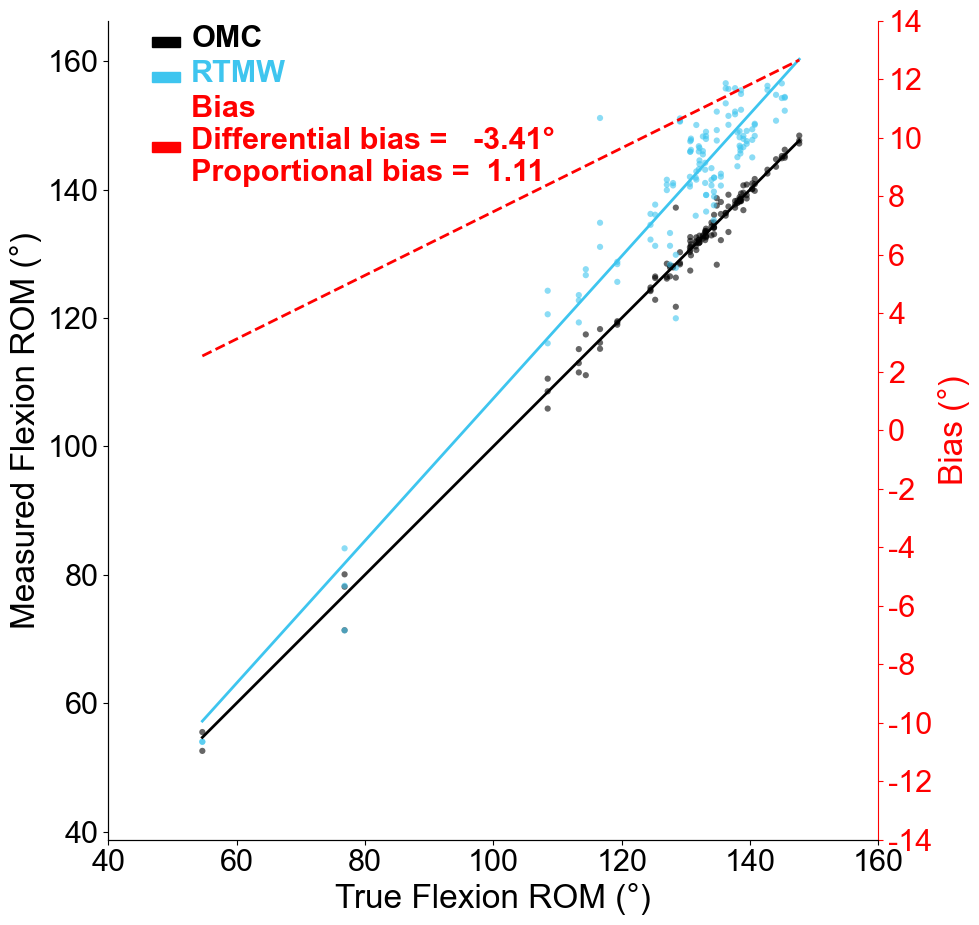

In [55]:
fig = generate_bias_plot_py(flexion_rtmw, method ='RTMW', motion ='flexion', alpha=alpha)
fig.savefig(f"{save_path}/04_bias_plot_flexion_rtmw.pdf", bbox_inches='tight', dpi=300)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Generating Bias Plot ...


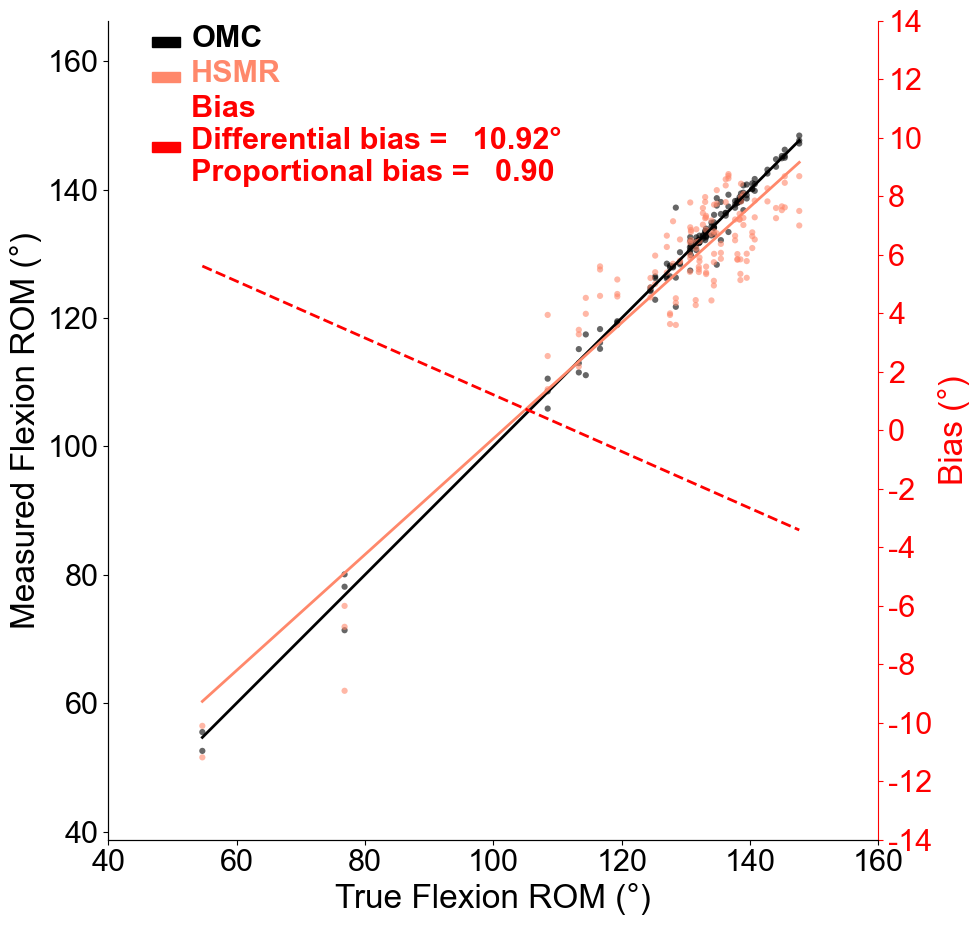

In [56]:
# Call the plotting function with the loaded data
fig = generate_bias_plot_py(flexion_hsmr, method ='HSMR', motion ='flexion', alpha=alpha)
fig.savefig(f"{save_path}/04_bias_plot_flexion_hsmr.pdf", bbox_inches='tight', dpi=300)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Generating Bias Plot ...


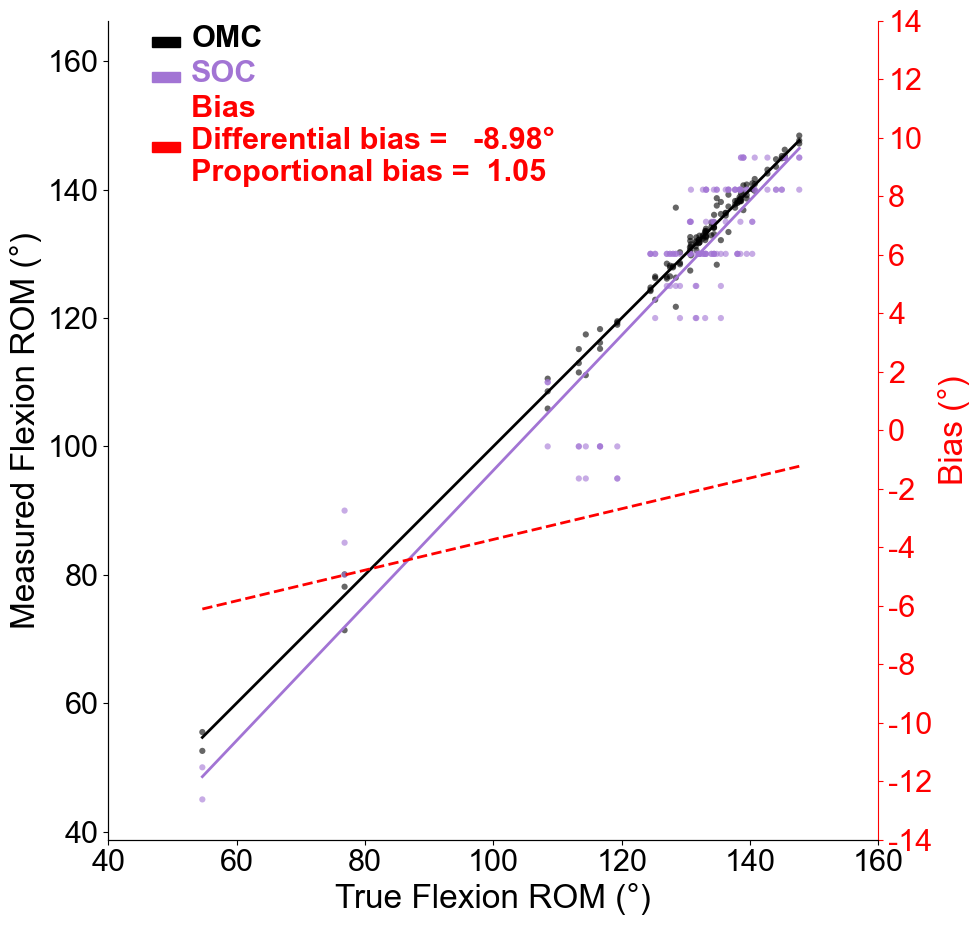

In [57]:
fig = generate_bias_plot_py(flexion_soc, method ='SOC', motion ='flexion', alpha=alpha)
fig.savefig(f"{save_path}/04_bias_plot_flexion_soc.pdf", bbox_inches='tight', dpi=300)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Generating Bias Plot ...


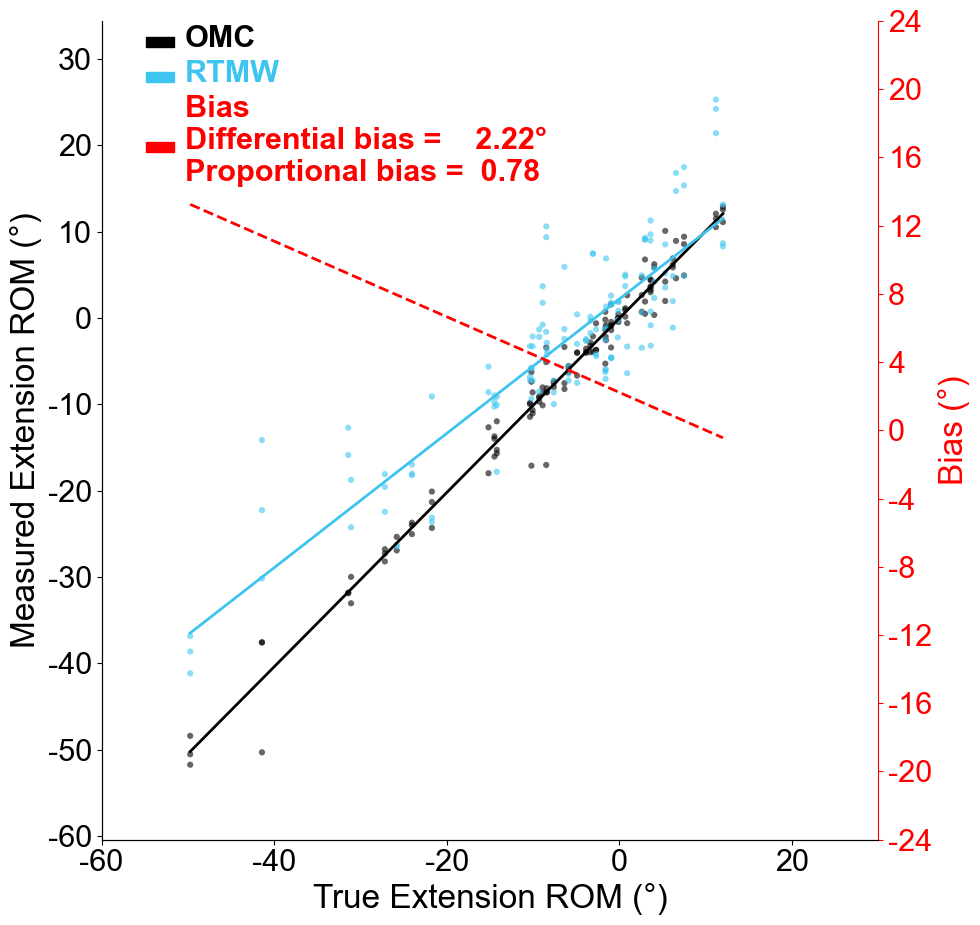

In [58]:
fig = generate_bias_plot_py(extension_rtmw, method ='RTMW', motion ='extension', alpha=alpha)
fig.savefig(f"{save_path}/04_bias_plot_extension_rtmw.pdf", bbox_inches='tight', dpi=300)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Generating Bias Plot ...


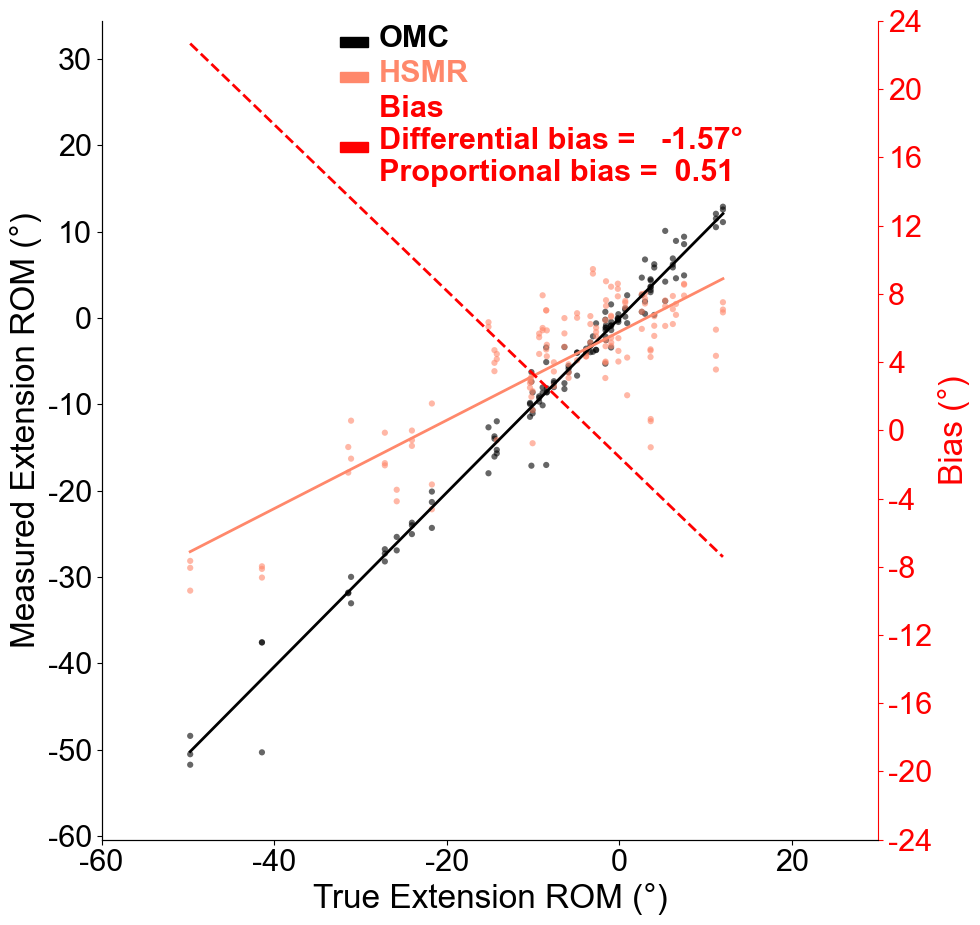

In [59]:
fig = generate_bias_plot_py(extension_hsmr, method ='HSMR', motion ='extension', alpha=alpha)
fig.savefig(f"{save_path}/04_bias_plot_extension_hsmr.pdf", bbox_inches='tight', dpi=300)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Generating Bias Plot ...


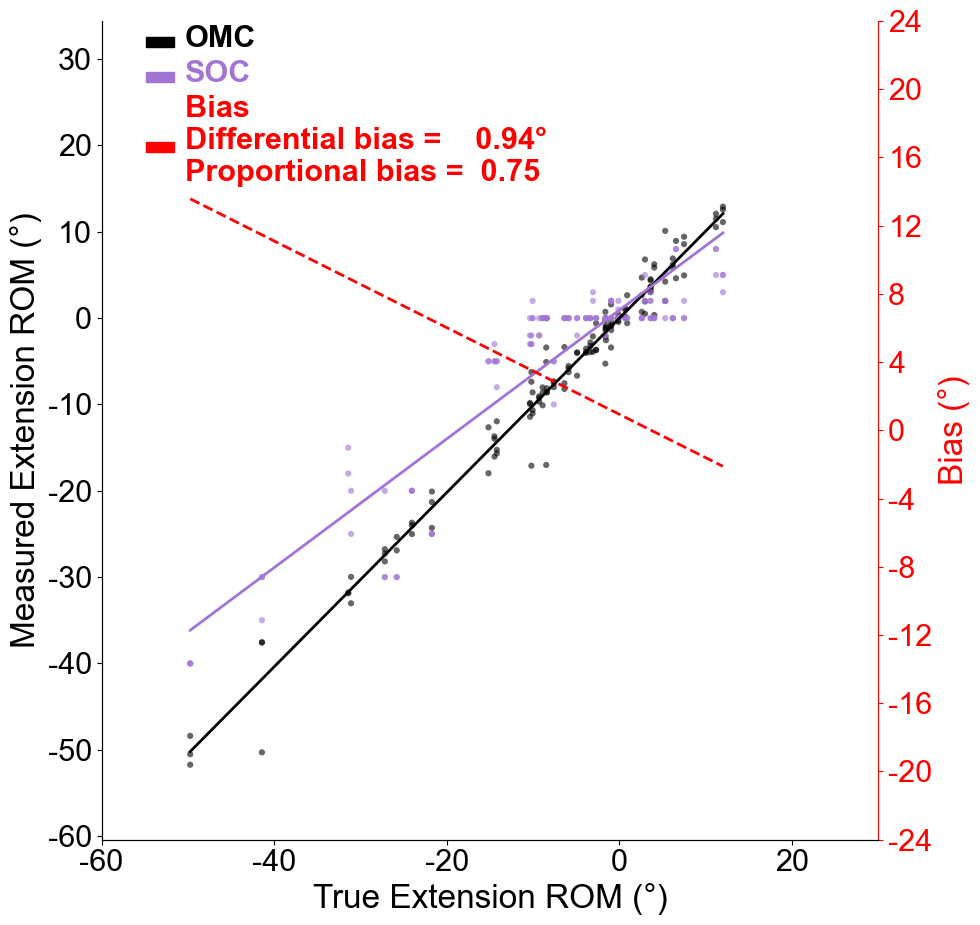

In [60]:
fig = generate_bias_plot_py(extension_soc, method ='SOC', motion ='extension', alpha=alpha)
fig.savefig(f"{save_path}/04_bias_plot_extension_soc.pdf", bbox_inches='tight', dpi=300)

Generating Comparison Precision Plot ...


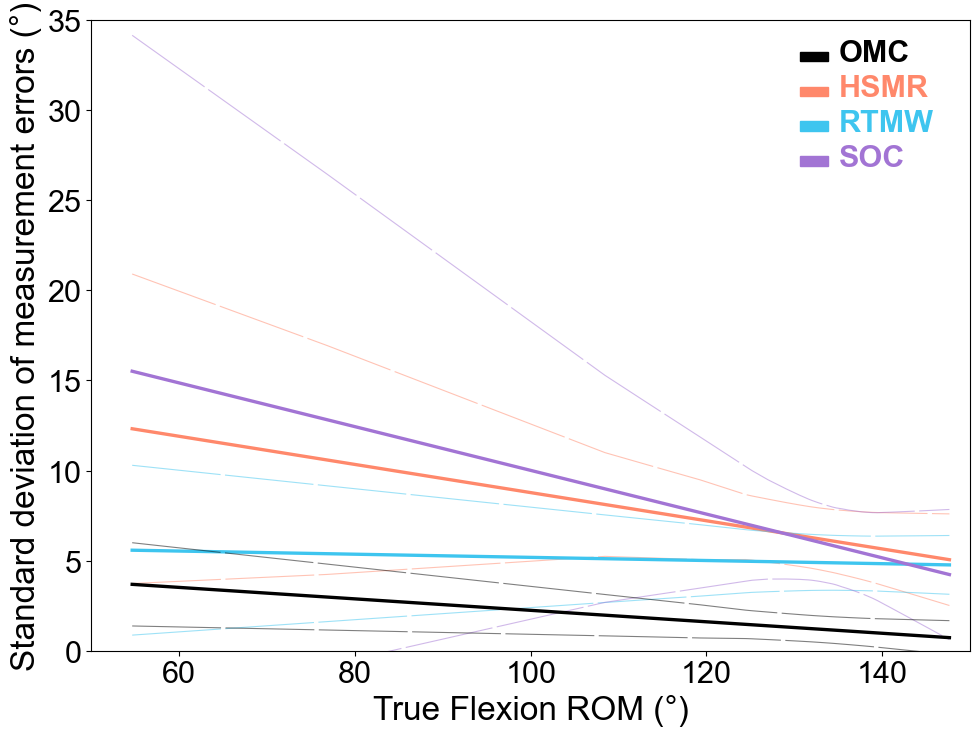

In [61]:
fig = generate_comparison_precision_plot(flexion_hsmr, flexion_rtmw, flexion_soc, motion='flexion', method1='HSMR', method2='RTMW', method3='SOC', omc=True)
fig.savefig(f"{save_path}/04_comparison_precision_plot_flexion.pdf", bbox_inches='tight', dpi=300)

Generating Comparison Precision Plot ...


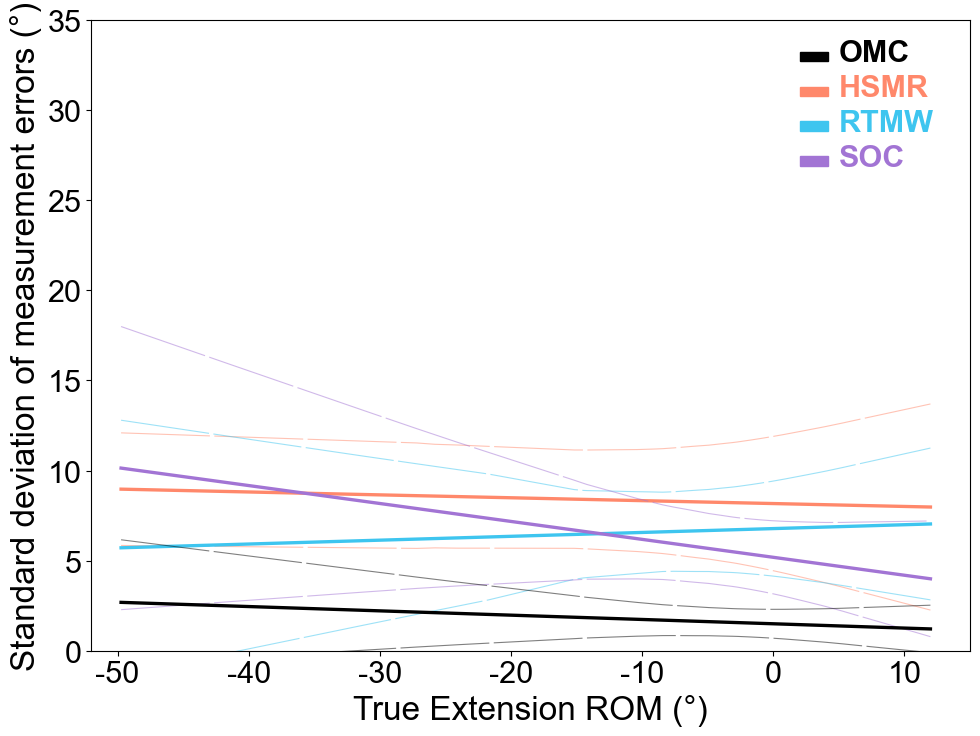

In [62]:
fig = generate_comparison_precision_plot(extension_hsmr, extension_rtmw, extension_soc, motion='extension', method1='HSMR', method2='RTMW', method3='SOC', omc=True)
fig.savefig(f"{save_path}/04_comparison_precision_plot_extension.pdf", bbox_inches='tight', dpi=300)